<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **AI Workload Readiness Assessment**

Estimated time needed: **40** minutes


## Overview

This lab is designed for data engineers who need to determine whether an existing analytics platform can safely support AI workloads in production.

You will build a practical readiness assessment workflow that measures:
- serving behavior under inference load,
- freshness risk under distribution shift,
- observability coverage for model operations.

Real-world use cases include migration planning from BI platforms to AI-enabled platforms, production hardening of model APIs, and governance reviews before deployment.

By the end of this lab, you will produce a readiness scorecard and targeted platform improvement recommendations.


# __Table of Contents__

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Overview">Overview</a></li>
        <li><a href="#Materials-and-Methods">Materials and Methods</a></li>
        <li><a href="#Dataset-Requirements-and-Licensing">Dataset Requirements and Licensing</a></li>
        <li><a href="#Objectives">Objectives</a></li>
        <li><a href="#Setup,-Installations,-and-Data-Checks">Setup, Installations, and Data Checks</a></li>
        <li><a href="#Baseline-Assessment">Baseline Assessment</a></li>
        <li><a href="#Serving-Readiness">Serving Readiness</a></li>
        <li><a href="#Freshness-Readiness">Freshness Readiness</a></li>
        <li><a href="#Observability-Readiness">Observability Readiness</a></li>
        <li><a href="#Practice-Tasks">Practice Tasks</a></li>
        <li><a href="#Author">Author</a></li>
    </ol>
</div>

<hr>


## Materials and Methods

This lab uses a supervised readiness pipeline based on:
- **[Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)**,
- **[StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)**,
- **[LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)**,
- optional comparison with **[RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)**.

Architectural Trade-offs addressed in this lab:
- speed vs. accuracy,
- latency vs. memory constraints,
- monitoring depth vs. operational overhead.


## Dataset Requirements and Licensing

This lab uses the built-in `load_breast_cancer` dataset from `sklearn.datasets` to ensure stable, reproducible execution in classroom and enterprise sandbox environments.

Source: **[scikit-learn toy datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset)**.

This dataset is distributed as part of scikit-learn under the BSD family license. This dataset is provided under the <a href="https://opensource.org/licenses/BSD-3-Clause" target="_blank">BSD 3-Clause</a> license and is safe for commercial use.


## Objectives

After completing this lab, you will be able to:
- Assess whether an existing platform can support AI workloads.
- Recommend improvements for serving, freshness, and observability readiness.
- Apply governance-style Data Quality Checks before AI model deployment.
- Communicate readiness findings as a practical engineering scorecard.


## Setup, Installations, and Data Checks

First, install the required packages. In enterprise workflows, pinning this setup step at the top of the notebook reduces environment drift across CI/CD stages and developer machines.


In [1]:
# Install all required libraries in quiet mode for reproducibility.
# Keeping setup deterministic helps enterprise deployment reliability.
%pip install -q pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


If package installation completed without errors, continue to imports. Warnings about already-installed packages are normal and safe.

Next, import all libraries in one dedicated step so the runtime dependencies are explicit and auditable.


In [2]:
# Import foundational numerical and tabular libraries.
import numpy as np
import pandas as pd

# Import plotting libraries for readiness reporting visuals.
import matplotlib.pyplot as plt
import seaborn as sns

# Import dataset and train/test split utility from scikit-learn.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Import pipeline and model components for serving experiments.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics used in readiness scoring.
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Import precise timer to benchmark inference latency.
from time import perf_counter

# Set a clean visual style for consistency.
sns.set_theme(style="whitegrid")

With dependencies loaded, we can start the benchmark workflow.

## Baseline Assessment

In this section, we load a stable built-in dataset and create a baseline model quality reference that will later be compared against serving, freshness, and observability constraints.


In [3]:
# Load the built-in breast cancer dataset in DataFrame form.
dataset_bundle = load_breast_cancer(as_frame=True)

# Split feature matrix and target labels for supervised learning.
features = dataset_bundle.data.copy()
target = dataset_bundle.target.copy()

# Build a combined profiling frame for governance checks.
df = features.copy()
df["target"] = target

# Print basic shape information for context.
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Display the first records to verify data loading.
display(df.head())

Rows: 569, Columns: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Data loads correctly and is now ready for governance-style validation.

Run explicit Data Quality Checks next to align with enterprise CI/CD and data contract expectations.


In [ ]:
# Create a dedicated frame for quality checks.
quality_df = df.copy()

# Check null counts to verify data completeness.
null_counts = quality_df.isnull().sum()

# Check duplicate rows to avoid training leakage.
duplicate_rows = quality_df.duplicated().sum()

# Validate schema: all feature columns should be numeric.
feature_columns = quality_df.columns.drop("target")
non_numeric_columns = (
    quality_df[feature_columns].select_dtypes(exclude=["number"]).columns.tolist()
)

# Inspect class balance for stable split behavior.
class_distribution = quality_df["target"].value_counts(normalize=True).sort_index()

# Print governance checks in a concise summary.
print(f"Total null values: {int(null_counts.sum())}")
print(f"Duplicate rows: {int(duplicate_rows)}")
print(
    f"Non-numeric feature columns: {non_numeric_columns if non_numeric_columns else 'None'}"
)
print("Class distribution (0 = malignant, 1 = benign):")
display(class_distribution.rename("ratio"))

Total null values: 0
Duplicate rows: 0
Non-numeric feature columns: None
Class distribution (0 = malignant, 1 = benign):


target
0    0.372583
1    0.627417
Name: ratio, dtype: float64

These checks are critical quality gates. If they fail in production, data ingestion should be blocked.

Next, we train a baseline classifier to establish a model quality reference before assessing platform readiness dimensions.


In [5]:
# Split data with stratification to preserve label distribution.
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.25,
    random_state=42,
    stratify=target,
)

# Build a baseline pipeline for fast and explainable serving.
readiness_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=42)),
    ]
)

# Train the baseline model on the training split.
readiness_model.fit(X_train, y_train)

# Run holdout predictions for quality measurement.
y_pred = readiness_model.predict(X_test)

# Compute core quality metrics for readiness context.
baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
}

# Print metrics and a detailed class report.
print("Baseline model quality metrics:")
print({k: round(v, 4) for k, v in baseline_metrics.items()})
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

Baseline model quality metrics:
{'accuracy': 0.986, 'f1_weighted': 0.986}

Classification report:
              precision    recall  f1-score   support

           0     0.9811    0.9811    0.9811        53
           1     0.9889    0.9889    0.9889        90

    accuracy                         0.9860       143
   macro avg     0.9850    0.9850    0.9850       143
weighted avg     0.9860    0.9860    0.9860       143



The baseline quality result is one side of readiness. Production systems also require strict serving SLAs.

## Serving Readiness

Now we measure single-request and mini-batch latency to estimate p50, p95, and throughput behavior.


In [ ]:
# Define a helper function for repeated latency sampling.
def measure_latency_ms(model_obj, input_frame, repeat_runs=200):
    latency_samples = []

    # Run repeated predictions to build latency distribution.
    for _ in range(repeat_runs):
        start_time = perf_counter()
        _ = model_obj.predict(input_frame)
        end_time = perf_counter()

        # Convert elapsed time to milliseconds.
        latency_samples.append((end_time - start_time) * 1000)

    return np.array(latency_samples)


# Benchmark latency for a single-row request.
single_request = X_test.iloc[[0]]
single_latencies_ms = measure_latency_ms(
    readiness_model, single_request, repeat_runs=250
)

# Benchmark latency for a mini-batch request.
batch_request = X_test.iloc[:64]
batch_latencies_ms = measure_latency_ms(readiness_model, batch_request, repeat_runs=250)

# Aggregate serving metrics used in SLO discussions.
serving_metrics = {
    "p50_single_ms": float(np.percentile(single_latencies_ms, 50)),
    "p95_single_ms": float(np.percentile(single_latencies_ms, 95)),
    "p50_batch_ms": float(np.percentile(batch_latencies_ms, 50)),
    "p95_batch_ms": float(np.percentile(batch_latencies_ms, 95)),
    "throughput_rows_per_sec": float(
        len(batch_request) / (batch_latencies_ms.mean() / 1000)
    ),
}

# Display serving metrics in a readable table.
display(pd.DataFrame([serving_metrics]).round(3))

,p50_single_ms,p95_single_ms,p50_batch_ms,p95_batch_ms,throughput_rows_per_sec
0,0.895,1.866,0.893,1.415,65476.918


Focus on p95 as tail-latency risk. Strong average latency can still hide poor user experience under load spikes.

## Freshness Readiness

Next, we simulate distribution shift and convert drift magnitude into a freshness readiness score.


In [7]:
# Create a synthetic recent batch by shifting selected features.
recent_batch = X_test.copy()
recent_batch["mean radius"] = recent_batch["mean radius"] * 1.08
recent_batch["mean texture"] = recent_batch["mean texture"] * 1.05

# Compute normalized drift based on train-time mean and std.
train_means = X_train.mean()
train_stds = X_train.std(ddof=0).replace(0, 1)
drift_zscores = ((recent_batch.mean() - train_means).abs() / train_stds).fillna(0)

# Capture top shifted features for root-cause review.
top_shifted_features = drift_zscores.sort_values(ascending=False).head(8)

# Convert average drift into a freshness readiness score.
average_drift = float(drift_zscores.mean())
freshness_score = float(max(0, 100 - (average_drift * 30)))

# Print summary and display the highest-drift features.
print(f"Average normalized drift: {average_drift:.3f}")
print(f"Freshness readiness score: {freshness_score:.1f}/100")
display(top_shifted_features.rename("normalized_drift"))

Average normalized drift: 0.075
Freshness readiness score: 97.7/100


mean radius        0.385147
mean texture       0.212083
mean symmetry      0.138236
area error         0.112364
symmetry error     0.111275
mean smoothness    0.102220
worst concavity    0.100209
radius error       0.094530
Name: normalized_drift, dtype: float64

Rising drift signals stale features, delayed ingestion, or retraining gaps.

## Observability Readiness

Now combine serving, freshness, model quality, and quality controls into a single readiness scorecard with concrete recommendations.


In [ ]:
# Assign serving score using practical p95 latency thresholds.
if serving_metrics["p95_single_ms"] <= 20:
    serving_score = 100
elif serving_metrics["p95_single_ms"] <= 40:
    serving_score = 80
elif serving_metrics["p95_single_ms"] <= 80:
    serving_score = 60
else:
    serving_score = 40

# Convert baseline model quality to a percentage score.
model_quality_score = baseline_metrics["f1_weighted"] * 100

# Reuse freshness score from drift assessment.
freshness_dimension_score = freshness_score

# Compute data quality pass rate as observability input.
quality_checks_total = 3
quality_checks_passed = 0
quality_checks_passed += int(null_counts.sum() == 0)
quality_checks_passed += int(duplicate_rows == 0)
quality_checks_passed += int(len(non_numeric_columns) == 0)
data_quality_pass_rate = (quality_checks_passed / quality_checks_total) * 100

# Estimate observability score from coverage and quality controls.
tracked_metrics = ["accuracy", "f1_weighted", "p95_single_ms", "average_drift"]
coverage_score = min(len(tracked_metrics) * 20, 100)
observability_score = (0.6 * coverage_score) + (0.4 * data_quality_pass_rate)

# Apply weighted aggregation to produce overall readiness.
weights = {
    "serving": 0.35,
    "freshness": 0.30,
    "observability": 0.20,
    "model_quality": 0.15,
}
overall_readiness_score = (
    (weights["serving"] * serving_score)
    + (weights["freshness"] * freshness_dimension_score)
    + (weights["observability"] * observability_score)
    + (weights["model_quality"] * model_quality_score)
)

# Generate recommendation list tied to observed readiness signals.
recommendations = []
if serving_metrics["p95_single_ms"] > 20:
    recommendations.append(
        "Deploy a low-latency serving layer with request batching and autoscaling."
    )
if average_drift > 0.7:
    recommendations.append(
        "Add drift alerts and retraining triggers to improve freshness readiness."
    )
if observability_score < 85:
    recommendations.append(
        "Increase observability coverage for latency, drift, and quality metrics."
    )
if model_quality_score < 92:
    recommendations.append("Tune model threshold or evaluate ensemble alternatives.")
if not recommendations:
    recommendations.append(
        "Platform is close to AI-ready. Focus on production hardening and runbook automation."
    )

# Assemble a scorecard table for communication.
readiness_report = pd.DataFrame(
    {
        "dimension": [
            "Serving",
            "Freshness",
            "Observability",
            "Model Quality",
            "Overall",
        ],
        "score": [
            serving_score,
            freshness_dimension_score,
            observability_score,
            model_quality_score,
            overall_readiness_score,
        ],
    }
).round(2)

# Display scorecard and recommendation list.
display(readiness_report)
print("Recommended improvements:")
for idx, item in enumerate(recommendations, start=1):
    print(f"{idx}. {item}")

,dimension,score
0,Serving,100.00
1,Freshness,97.74
2,Observability,88.00
3,Model Quality,98.60
4,Overall,96.71


Recommended improvements:
1. Platform is close to AI-ready. Focus on production hardening and runbook automation.


This scorecard makes Architectural Trade-offs explicit and helps prioritize modernization actions.

Now plot readiness dimensions to quickly identify bottlenecks for platform planning discussions.


/tmp/ipykernel_10516/1861485458.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=readiness_report, x="dimension", y="score", palette="Blues_d")


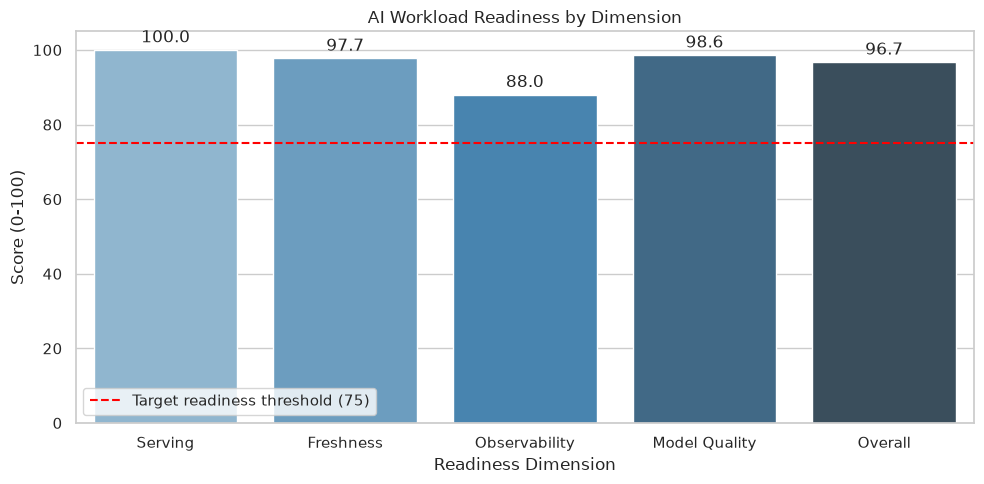

In [ ]:
# Plot readiness scores by dimension for quick interpretation.
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=readiness_report, x="dimension", y="score", palette="Blues_d")

# Add target threshold to indicate acceptable readiness level.
plt.axhline(
    75,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Target readiness threshold (75)",
)

# Annotate each bar with the numeric score.
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(
        f"{height:.1f}",
        (patch.get_x() + patch.get_width() / 2, height + 1),
        ha="center",
        va="bottom",
    )

# Finalize chart labels and layout.
plt.title("AI Workload Readiness by Dimension")
plt.xlabel("Readiness Dimension")
plt.ylabel("Score (0-100)")
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()
plt.show()

## Practice Tasks

The chart highlights where remediation should start. Apply your own engineering judgment with the following tasks.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1: </h1>
<b>Adjust the readiness score weights to prioritize freshness over serving latency, then recompute the overall score and explain whether your platform decision changes.</b>
</div>


In [ ]:
# TODO: Create a custom weight dictionary that prioritizes freshness.
# TODO: Recalculate the overall readiness score with your new weights.
# TODO: Decide if the platform is production-ready using your threshold.

# Prioritize freshness for rapidly changing data domains.
freshness_first_weights = {
    "serving": 0.25,
    "freshness": 0.45,
    "observability": 0.20,
    "model_quality": 0.10,
}

# Recalculate weighted readiness with new priorities.
freshness_first_score = (
    (freshness_first_weights["serving"] * serving_score)
    + (freshness_first_weights["freshness"] * freshness_dimension_score)
    + (freshness_first_weights["observability"] * observability_score)
    + (freshness_first_weights["model_quality"] * model_quality_score)
)

# Print score and a simple deployment decision.
print(f"Freshness-priority readiness score: {freshness_first_score:.2f}")
print(
    "Production-ready" if freshness_first_score >= 75 else "Needs platform improvements"
)

Freshness-priority readiness score: 96.45
Production-ready


<details><summary>Click here for the solution</summary>

```python
# Prioritize freshness for rapidly changing data domains.
freshness_first_weights = {
    "serving": 0.25,
    "freshness": 0.45,
    "observability": 0.20,
    "model_quality": 0.10,
}

# Recalculate weighted readiness with new priorities.
freshness_first_score = (
    (freshness_first_weights["serving"] * serving_score)
    + (freshness_first_weights["freshness"] * freshness_dimension_score)
    + (freshness_first_weights["observability"] * observability_score)
    + (freshness_first_weights["model_quality"] * model_quality_score)
)

# Print score and a simple deployment decision.
print(f"Freshness-priority readiness score: {freshness_first_score:.2f}")
print("Production-ready" if freshness_first_score >= 75 else "Needs platform improvements")
```

</details>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #2: </h1>
<b>Train a Random Forest baseline and compare its F1 score and p95 single-request latency against the Logistic Regression pipeline. Based on the trade-off, recommend which model to deploy first.</b>
</div>


In [ ]:
# TODO: Train a RandomForestClassifier on X_train and y_train.
# TODO: Compute weighted F1 on X_test.
# TODO: Measure p95 single-row latency and compare with the baseline model.

# Train a random forest model for trade-off comparison.
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluate weighted F1 on holdout data.
rf_pred = rf_model.predict(X_test)
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

# Measure p95 single-row latency for the random forest model.
rf_single_latencies = measure_latency_ms(rf_model, X_test.iloc[[0]], repeat_runs=250)
rf_p95_single_ms = float(np.percentile(rf_single_latencies, 95))

# Build a comparison table for deployment discussion.
comparison_df = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "f1_weighted": baseline_metrics["f1_weighted"],
            "p95_single_ms": serving_metrics["p95_single_ms"],
        },
        {
            "model": "Random Forest",
            "f1_weighted": rf_f1,
            "p95_single_ms": rf_p95_single_ms,
        },
    ]
).round(4)

display(comparison_df)

# Print a recommendation based on quality and latency trade-off.
if (
    comparison_df.loc[1, "f1_weighted"] > comparison_df.loc[0, "f1_weighted"]
    and comparison_df.loc[1, "p95_single_ms"]
    <= 1.5 * comparison_df.loc[0, "p95_single_ms"]
):
    print(
        "Recommendation: Deploy Random Forest first for better quality with acceptable latency overhead."
    )
else:
    print(
        "Recommendation: Deploy Logistic Regression first for stronger latency predictability."
    )

,model,f1_weighted,p95_single_ms
0,Logistic Regression,0.9860,1.8655
1,Random Forest,0.9579,79.9629


Recommendation: Deploy Logistic Regression first for stronger latency predictability.


<details><summary>Click here for the solution</summary>

```python
# Train a random forest model for trade-off comparison.
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluate weighted F1 on holdout data.
rf_pred = rf_model.predict(X_test)
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

# Measure p95 single-row latency for the random forest model.
rf_single_latencies = measure_latency_ms(rf_model, X_test.iloc[[0]], repeat_runs=250)
rf_p95_single_ms = float(np.percentile(rf_single_latencies, 95))

# Build a comparison table for deployment discussion.
comparison_df = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "f1_weighted": baseline_metrics["f1_weighted"],
            "p95_single_ms": serving_metrics["p95_single_ms"],
        },
        {
            "model": "Random Forest",
            "f1_weighted": rf_f1,
            "p95_single_ms": rf_p95_single_ms,
        },
    ]
).round(4)

display(comparison_df)

# Print a recommendation based on quality and latency trade-off.
if comparison_df.loc[1, "f1_weighted"] > comparison_df.loc[0, "f1_weighted"] and comparison_df.loc[1, "p95_single_ms"] <= 1.5 * comparison_df.loc[0, "p95_single_ms"]:
    print("Recommendation: Deploy Random Forest first for better quality with acceptable latency overhead.")
else:
    print("Recommendation: Deploy Logistic Regression first for stronger latency predictability.")
```

</details>

This completes the readiness evaluation workflow. You can extend this template with feature store metrics, model registry events, and production telemetry pipelines.


## Author

<a href="https://author.skills.network/instructors/dmytro_shliakhovskyi">Dmytro Shliakhovskyi</a>

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2026-04-10 | 01 | Dmytro Shliakhovskyi | Lab created |

<h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
